# Phase 9: Model Explainability

This notebook analyzes feature importance and interprets model predictions.

## Global Feature Importance

The model uses logistic regression, where each feature is associated with a coefficient that represents its influence on churn prediction.

- **Positive coefficients** indicate that the feature increases the likelihood of churn.
- **Negative coefficients** indicate that the feature reduces the likelihood of churn.

### Key Insights

- Features with high positive importance contribute strongly towards predicting churn.
- Features with high negative importance contribute towards predicting customer retention.

This helps in identifying the most critical factors affecting customer churn at a global level.

### Needful Imports

In [32]:
import pandas as pd
import numpy as np
import joblib

import _setup
from src.config import MODEL_DIR, DATA_PATH
from src.preprocess import preprocess_inf

print('loaded all dependencies successfully...')

loaded all dependencies successfully...


### Loading the model

In [14]:
# Loading the model
model = joblib.load(MODEL_DIR/'model.pkl')
columns = joblib.load(MODEL_DIR/'model_columns.pkl')

print('loaded the model successfully...')

loaded the model successfully...


### Feature Importance
Here we extract the coefficients of each feature in the model and see how much they matter in every prediction

In [41]:
from numpy import negative


coefficients = model.coef_[0]

importance_df = pd.DataFrame({
    "Feature": columns,
    "Importance": coefficients,
    "AbsImportance": abs(coefficients)
}).sort_values(by='AbsImportance', ascending=False).reset_index(drop=True)

display(importance_df.head(10))


,Feature,Importance,AbsImportance
0,Contract_Two year,-1.412536,1.412536
1,InternetService_Fiber optic,1.222352,1.222352
2,tenure,-1.156175,1.156175
3,Contract_One year,-0.715268,0.715268
4,MonthlyCharges,-0.546189,0.546189
5,TotalCharges,0.486541,0.486541
6,StreamingMovies_Yes,0.420611,0.420611
7,PaymentMethod_Electronic check,0.402478,0.402478
8,StreamingTV_Yes,0.395359,0.395359
9,PhoneService,-0.348014,0.348014


### Visualizing the Weights
We visualize the data obtained in the previous cell

<Axes: ylabel='Feature'>

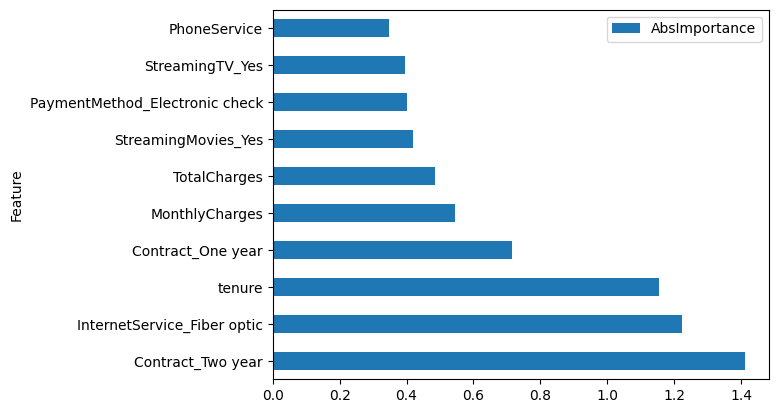

In [43]:
importance_df.head(10).plot(x="Feature", y="AbsImportance", kind='barh')

## Local Explanation (Per Customer)

To understand individual predictions, we compute feature contributions by multiplying feature values with model coefficients.

- Each feature contributes positively or negatively to the final prediction.
- Higher absolute contribution indicates a stronger influence on the prediction.

### Interpretation

- Features with high positive contribution push the prediction towards churn.
- Features with high negative contribution push the prediction towards non-churn.

This allows us to explain **why a specific customer is predicted to churn or stay**, making the model more interpretable.

In [38]:
data = pd.read_csv(DATA_PATH)

data = data.drop('Churn', axis=1)
random_indice = np.random.randint(0, data.shape[0])

sample = pd.DataFrame(data.iloc[[random_indice]])
sample = preprocess_inf(sample)
sample = sample.iloc[0]

contributions = sample * coefficients

contrib_df = pd.DataFrame({
    'Feature': sample.index,
    'Contribution': contributions,
    'AbsContribution': abs(contributions)
}).sort_values(by='AbsContribution', ascending=False).reset_index(drop=True)

display(contrib_df.head(5))


,Feature,Contribution,AbsContribution
0,tenure,-1.765563,1.765563
1,TotalCharges,0.621960,0.621960
2,PhoneService,-0.348014,0.348014
3,PaperlessBilling,0.336449,0.336449
4,MonthlyCharges,-0.191576,0.191576


## Final Summary

In this phase, we enhanced the model by introducing explainability to better understand its predictions.

- Analyzed **global feature importance** using model coefficients to identify key drivers of churn
- Computed **local feature contributions** to explain individual predictions
- Distinguished between features that **increase** and **decrease** the likelihood of churn
- Improved model transparency by linking predictions to interpretable factors

This completes the project by transforming it from a predictive model into an **interpretable and user-friendly machine learning system**, enabling both accurate predictions and meaningful insights.